In [1]:
from utils.config import load_config, Configuration
import numpy as np

config = load_config("config.yaml")

In [2]:
rdm_1_path = "data/rdm_dir/subj_02/2_mask20_fullrdm_correlation_sample0.npy"
rdm_2_path = "data/rdm_dir/subj_02/2_mask20_fullrdm_correlation_sample1.npy"

rdm_1 = np.load(rdm_1_path)
rdm_2 = np.load(rdm_2_path)


In [6]:
# Masked betas shape: (85, 4776)

print(f"{rdm_1.shape}")
print(f"{rdm_2.shape}")


(3570,)
(3570,)


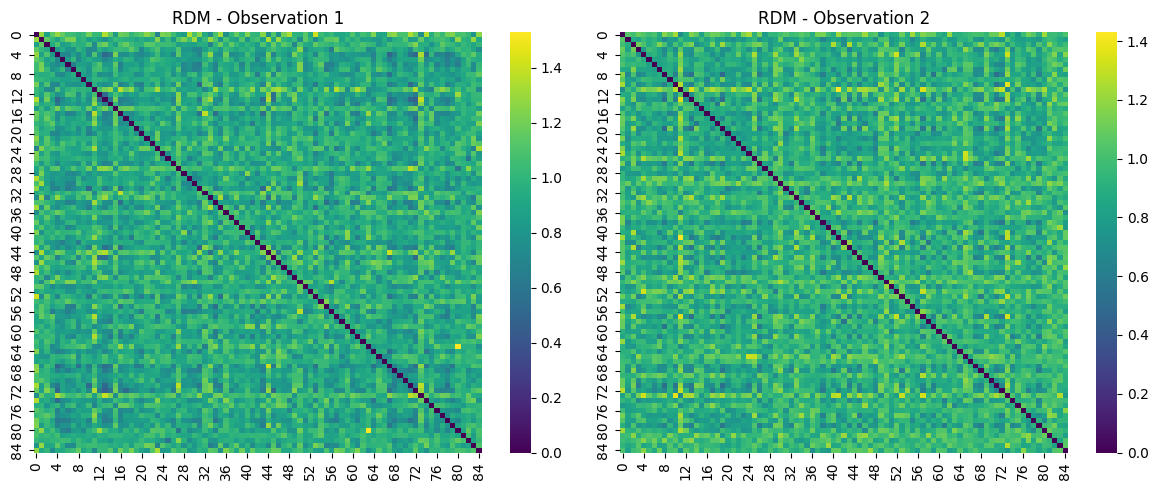

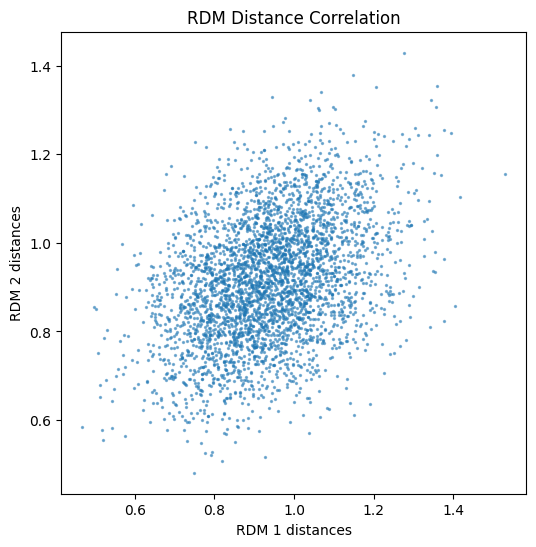

In [12]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import seaborn as sns

def compare_rdms(rdm1, rdm2, method='pearson'):
    """
    Compare two sets of observations using RDM correlation.
    
    Parameters:
    X1, X2 : numpy.ndarray
        Input matrices of shape (n_samples, n_features) for both observations
    method : str
        Correlation method ('pearson', 'spearman', or 'kendall')
        
    Returns:
    tuple : (correlation, p_value, rdm1, rdm2)
    """   
    # Calculate correlation
    if method == 'pearson':
        corr, p_value = pearsonr(rdm1, rdm2)
    elif method == 'spearman':
        corr, p_value = spearmanr(rdm1, rdm2)
    else:  # kendall
        corr, p_value = kendalltau(rdm1, rdm2)
    
    return corr, p_value, rdm1, rdm2


def visualize_rdm_comparison(rdm1, rdm2):
    """
    Create visualization to compare two RDMs.
    
    Parameters:
    rdm1, rdm2 : numpy.ndarray
        Condensed distance matrices from pdist
    """
    # Convert to square form for visualization
    square_rdm1 = squareform(rdm1)
    square_rdm2 = squareform(rdm2)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Plot RDMs
    sns.heatmap(square_rdm1, ax=ax1, cmap='viridis')
    ax1.set_title('RDM - Observation 1')
    
    sns.heatmap(square_rdm2, ax=ax2, cmap='viridis')
    ax2.set_title('RDM - Observation 2')
    
    plt.tight_layout()
    
    # Create scatter plot of RDM values
    plt.figure(figsize=(6, 6))
    plt.scatter(rdm1, rdm2, alpha=0.5, s=2)
    plt.xlabel('RDM 1 distances')
    plt.ylabel('RDM 2 distances')
    plt.title('RDM Distance Correlation')
    
corr, p_value, rdm1, rdm2 = compare_rdms(rdm_1, rdm_2)
visualize_rdm_comparison(rdm1, rdm2)